In [1]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split # أضفنا مكتبة التقسيم


In [2]:
print("جاري تحميل البيانات...")
path = kagglehub.dataset_download("brijbhushannanda1979/bigmart-sales-data")
file_path = os.path.join(path, "Train.csv")
df = pd.read_csv(file_path)
print("تم تحميل وقراءة البيانات بنجاح!\n")


جاري تحميل البيانات...


100%|██████████| 307k/307k [00:00<00:00, 447kB/s]

Extracting files...
تم تحميل وقراءة البيانات بنجاح!



In [3]:
display(df.head())

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


,0
Item_Identifier,0
Item_Weight,1463
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0


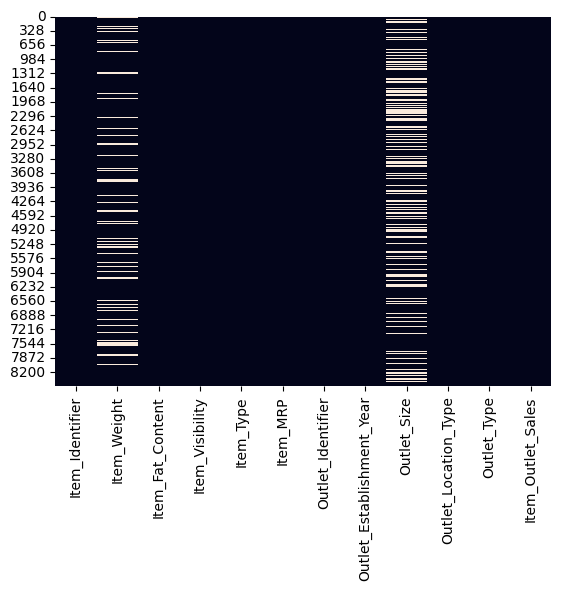

In [4]:
sns.heatmap(df.isnull(), cbar=False)
df.isnull().sum()

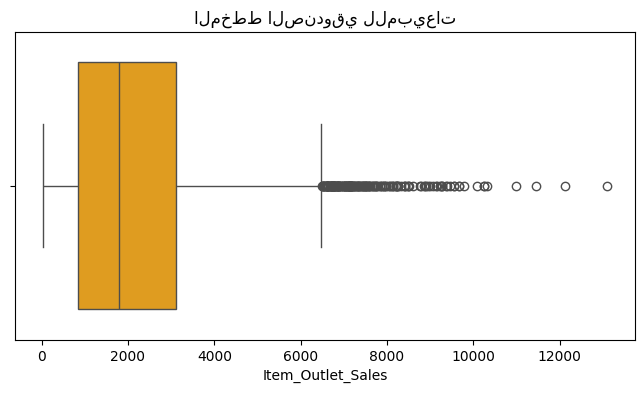

In [5]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Item_Outlet_Sales'], color='orange')
plt.title("المخطط الصندوقي للمبيعات")
plt.show()

In [6]:
Q1 = df['Item_Outlet_Sales'].quantile(0.25)
Q3 = df['Item_Outlet_Sales'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
print(f"\nأي قيمة مبيعات تتجاوز {upper_bound:.2f} سيتم تقليمها.")
df['Item_Outlet_Sales'] = np.where(df['Item_Outlet_Sales'] > upper_bound, upper_bound, df['Item_Outlet_Sales'])
print("تم تقليم القيم الشاذة في عمود المبيعات بنجاح!")



أي قيمة مبيعات تتجاوز 6501.87 سيتم تقليمها.
تم تقليم القيم الشاذة في عمود المبيعات بنجاح!


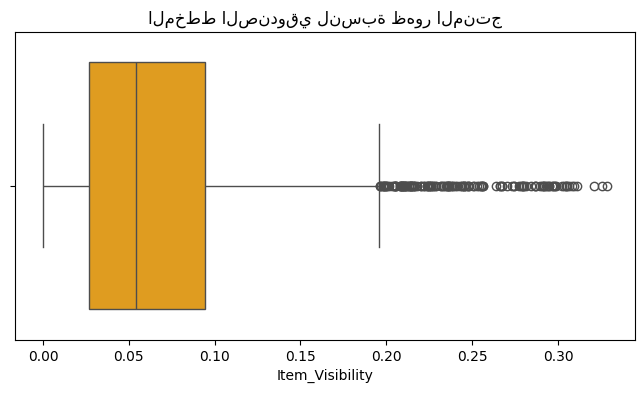

In [7]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Item_Visibility'], color='orange')
plt.title("المخطط الصندوقي لنسبة ظهور المنتج")
plt.show()

In [8]:
Q1 = df['Item_Visibility'].quantile(0.25)
Q3 = df['Item_Visibility'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
print(f"\nأي نسبة تتجاوز {upper_bound:.2f} سيتم تقليمها.")
df['Item_Visibility'] = np.where(df['Item_Visibility'] > upper_bound, upper_bound, df['Item_Visibility'])
print("تم تقليم القيم الشاذة في عمود نسبة ظهور المنتج!")



أي نسبة تتجاوز 0.20 سيتم تقليمها.
تم تقليم القيم الشاذة في عمود نسبة ظهور المنتج!


In [9]:
median_weight = df['Item_Weight'].median()
mode_size = df['Outlet_Size'].mode()[0]
df['Outlet_Size'].fillna(mode_size, inplace=True)
df['Item_Weight'].fillna(median_weight, inplace=True)

/tmp/ipykernel_18730/3241221838.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Outlet_Size'].fillna(mode_size, inplace=True)
/tmp/ipykernel_18730/3241221838.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', t

In [10]:
df['Item_Fat_Content'] = df['Item_Fat_Content'].replace({
    'LF': 'Low Fat',
    'low fat': 'Low Fat',
    'reg': 'Regular'
})


##Featuer Engneering

In [11]:
df['Outlet_Age']=2026-df['Outlet_Establishment_Year']

In [12]:
display(df['Outlet_Age'])

,Outlet_Age
0,27
1,17
2,27
3,28
4,39
...,...
8518,39
8519,24
8520,22
8521,17


In [13]:
categorical_cols = ['Item_Fat_Content', 'Item_Type', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type']
df=pd.get_dummies(df,columns=categorical_cols,drop_first=True)
df.head()

,Item_Identifier,Item_Weight,Item_Visibility,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Item_Outlet_Sales,Outlet_Age,Item_Fat_Content_Regular,Item_Type_Breads,...,Item_Type_Snack Foods,Item_Type_Soft Drinks,Item_Type_Starchy Foods,Outlet_Size_Medium,Outlet_Size_Small,Outlet_Location_Type_Tier 2,Outlet_Location_Type_Tier 3,Outlet_Type_Supermarket Type1,Outlet_Type_Supermarket Type2,Outlet_Type_Supermarket Type3
0,FDA15,9.30,0.016047,249.8092,OUT049,1999,3735.1380,27,False,False,...,False,False,False,True,False,False,False,True,False,False
1,DRC01,5.92,0.019278,48.2692,OUT018,2009,443.4228,17,True,False,...,False,True,False,True,False,False,True,False,True,False
2,FDN15,17.50,0.016760,141.6180,OUT049,1999,2097.2700,27,False,False,...,False,False,False,True,False,False,False,True,False,False
3,FDX07,19.20,0.000000,182.0950,OUT010,1998,732.3800,28,True,False,...,False,False,False,True,False,False,True,False,False,False
4,NCD19,8.93,0.000000,53.8614,OUT013,1987,994.7052,39,False,False,...,False,False,False,False,False,False,True,True,False,False


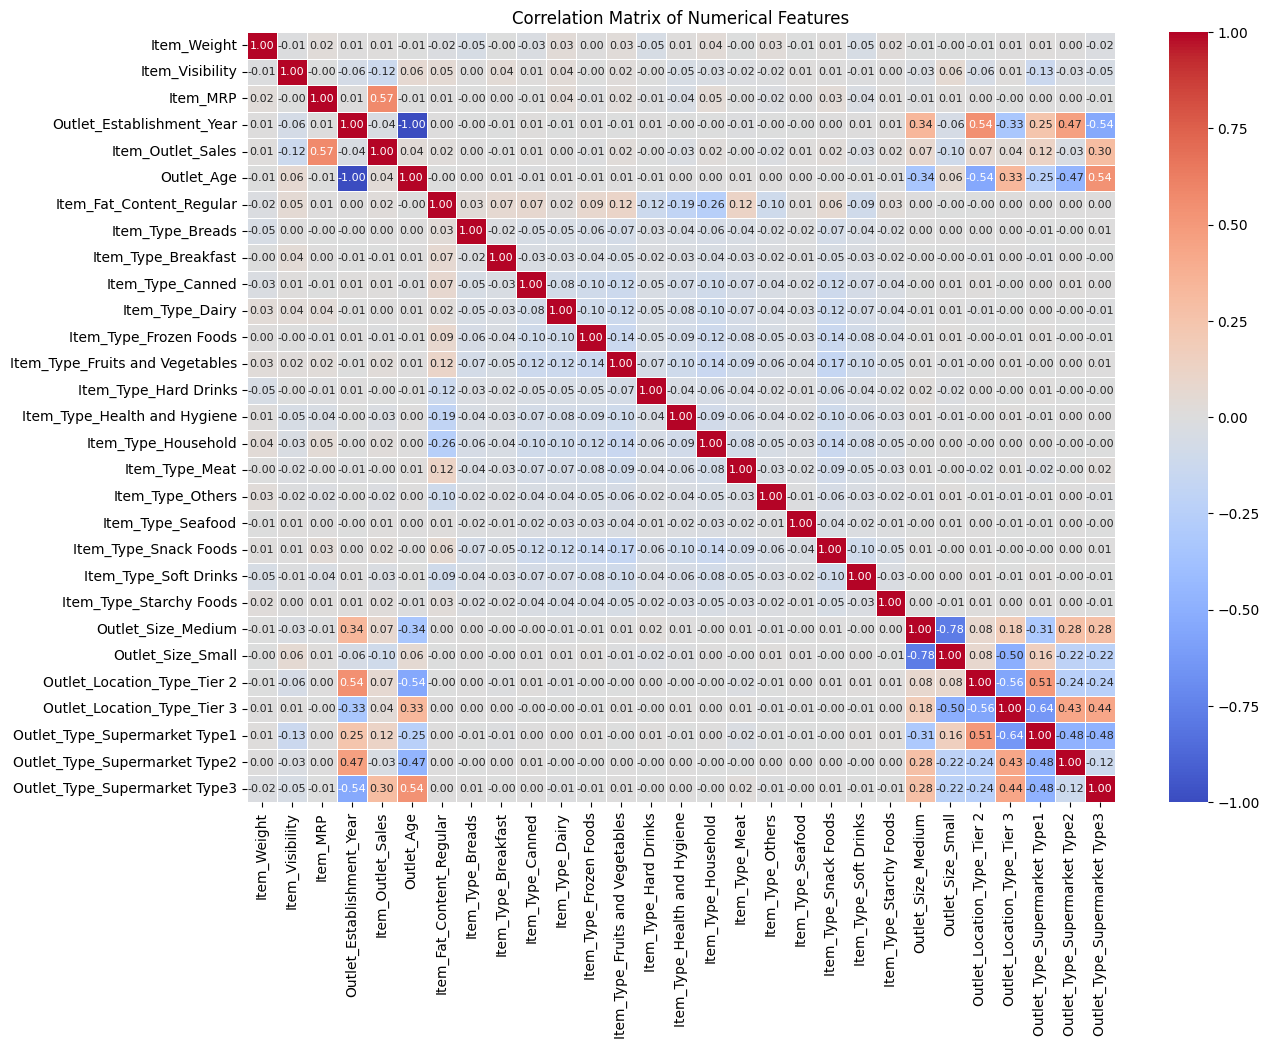

In [14]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(14, 10)) # Set a larger figure size
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, annot_kws={'size': 8}) # Add formatting and adjust annotation font size
plt.title('Correlation Matrix of Numerical Features') # Add a title for clarity
plt.show()

In [15]:
df['Item_Outlet_Sales'].sort_values(ascending=False)

,Item_Outlet_Sales
8447,6501.8699
1113,6501.8699
1127,6501.8699
1138,6501.8699
8350,6501.8699
...,...
7388,35.2874
3053,34.6216
2571,33.9558
6950,33.2900


In [16]:
df=df.drop(columns=['Item_Identifier','Outlet_Identifier','Outlet_Establishment_Year'])

In [17]:
display(df.head())

,Item_Weight,Item_Visibility,Item_MRP,Item_Outlet_Sales,Outlet_Age,Item_Fat_Content_Regular,Item_Type_Breads,Item_Type_Breakfast,Item_Type_Canned,Item_Type_Dairy,...,Item_Type_Snack Foods,Item_Type_Soft Drinks,Item_Type_Starchy Foods,Outlet_Size_Medium,Outlet_Size_Small,Outlet_Location_Type_Tier 2,Outlet_Location_Type_Tier 3,Outlet_Type_Supermarket Type1,Outlet_Type_Supermarket Type2,Outlet_Type_Supermarket Type3
0,9.30,0.016047,249.8092,3735.1380,27,False,False,False,False,True,...,False,False,False,True,False,False,False,True,False,False
1,5.92,0.019278,48.2692,443.4228,17,True,False,False,False,False,...,False,True,False,True,False,False,True,False,True,False
2,17.50,0.016760,141.6180,2097.2700,27,False,False,False,False,False,...,False,False,False,True,False,False,False,True,False,False
3,19.20,0.000000,182.0950,732.3800,28,True,False,False,False,False,...,False,False,False,True,False,False,True,False,False,False
4,8.93,0.000000,53.8614,994.7052,39,False,False,False,False,False,...,False,False,False,False,False,False,True,True,False,False


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Item_Weight                      8523 non-null   float64
 1   Item_Visibility                  8523 non-null   float64
 2   Item_MRP                         8523 non-null   float64
 3   Item_Outlet_Sales                8523 non-null   float64
 4   Outlet_Age                       8523 non-null   int64  
 5   Item_Fat_Content_Regular         8523 non-null   bool   
 6   Item_Type_Breads                 8523 non-null   bool   
 7   Item_Type_Breakfast              8523 non-null   bool   
 8   Item_Type_Canned                 8523 non-null   bool   
 9   Item_Type_Dairy                  8523 non-null   bool   
 10  Item_Type_Frozen Foods           8523 non-null   bool   
 11  Item_Type_Fruits and Vegetables  8523 non-null   bool   
 12  Item_Type_Hard Drink

In [19]:
scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df)

In [20]:
x=df.drop(columns=['Item_Outlet_Sales'])
y=df['Item_Outlet_Sales']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [21]:
print(f"حجم بيانات التدريب{x_train.shape}")
print(f"حجم بيانات الاختبار{x_test.shape}")

حجم بيانات التدريب(6818, 27)
حجم بيانات الاختبار(1705, 27)


In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score

print("******************************************")
print("(LinearRegression)انحدار اللوجستي")
print("******************************************")

dt_model = LinearRegression()
dt_model.fit(x_train, y_train)

r2_train = r2_score(y_train, dt_model.predict(x_train))
r2_test = r2_score(y_test, dt_model.predict(x_test))

print(f"R2 على بيانات التدريب: {r2_train:.2f}")
print(f"R2 على بيانات الاختبار: {r2_test:.2f}")
print("إذا كانت القيم متقاربة، فهذا يشير إلى نموذج مستقر.")


******************************************
(LinearRegression)انحدار اللوجستي
******************************************
R2 على بيانات التدريب: 0.57
R2 على بيانات الاختبار: 0.59
إذا كانت القيم متقاربة، فهذا يشير إلى نموذج مستقر.


In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score

print("******************************************")
print("(DecisionTreeRegressor)انحدار اللوجستي")
print("******************************************")

dtr_model = DecisionTreeRegressor()
dtr_model.fit(x_train, y_train)

r2_train = r2_score(y_train, dtr_model.predict(x_train))
r2_test = r2_score(y_test, dtr_model.predict(x_test))

print(f"R2 على بيانات التدريب: {r2_train:.2f}")
print(f"R2 على بيانات الاختبار: {r2_test:.2f}")
print("إذا كانت القيم متقاربة، فهذا يشير إلى نموذج مستقر.")


******************************************
(DecisionTreeRegressor)انحدار اللوجستي
******************************************
R2 على بيانات التدريب: 1.00
R2 على بيانات الاختبار: 0.22
إذا كانت القيم متقاربة، فهذا يشير إلى نموذج مستقر.


In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score

print("******************************************")
print("(DecisionTreeRegressor)انحدار اللوجستي")
print("******************************************")

dtr_model = DecisionTreeRegressor(max_depth=1)
dtr_model.fit(x_train, y_train)

r2_train = r2_score(y_train, dtr_model.predict(x_train))
r2_test = r2_score(y_test, dtr_model.predict(x_test))

print(f"R2 على بيانات التدريب: {r2_train:.2f}")
print(f"R2 على بيانات الاختبار: {r2_test:.2f}")
print("إذا كانت القيم متقاربة، فهذا يشير إلى نموذج مستقر.")


******************************************
(DecisionTreeRegressor)انحدار اللوجستي
******************************************
R2 على بيانات التدريب: 0.25
R2 على بيانات الاختبار: 0.24
إذا كانت القيم متقاربة، فهذا يشير إلى نموذج مستقر.


In [25]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score

print("******************************************")
print("(DecisionTreeRegressor)انحدار اللوجستي")
print("******************************************")

dtr_model = DecisionTreeRegressor(max_depth=6)
dtr_model.fit(x_train, y_train)

r2_train = r2_score(y_train, dtr_model.predict(x_train))
r2_test = r2_score(y_test, dtr_model.predict(x_test))

print(f"R2 على بيانات التدريب: {r2_train:.2f}")
print(f"R2 على بيانات الاختبار: {r2_test:.2f}")
print("إذا كانت القيم متقاربة، فهذا يشير إلى نموذج مستقر.")


******************************************
(DecisionTreeRegressor)انحدار اللوجستي
******************************************
R2 على بيانات التدريب: 0.63
R2 على بيانات الاختبار: 0.61
إذا كانت القيم متقاربة، فهذا يشير إلى نموذج مستقر.


In [26]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
print("******************************************")
print("الغابات العشوائية (Random Forest Classifier)")
print("******************************************")

rf_model = RandomForestRegressor(n_estimators=100,random_state=42)
rf_model.fit(x_train, y_train)

rf_train_acc=r2_score(y_train,rf_model.predict(x_train))

rf_test_acc=r2_score(y_test,rf_model.predict(x_test))

print(f"علامات التدريب: {rf_train_acc:.2f}")
print(f"علامات الاختبار: {rf_test_acc:.2f}")

******************************************
الغابات العشوائية (Random Forest Classifier)
******************************************
علامات التدريب: 0.94
علامات الاختبار: 0.57


In [27]:
from  sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import r2_score # Changed to r2_score for regression

print("******************************************")
print(" الجار الاقرب(KNeighbors Regressor)")
print("******************************************")

KN_model = KNeighborsRegressor(n_neighbors=5)
KN_model.fit(x_train, y_train)

r2_train = r2_score(y_train,KN_model.predict(x_train)) # Changed to r2_score

r2_test = r2_score(y_test,KN_model.predict(x_test)) # Changed to r2_score

print(f"R2 على بيانات التدريب: {r2_train*100:.2f}") # Updated print statement
print(f"R2 على بيانات الاختبار: {r2_test*100:.2f}") # Updated print statement

******************************************
 الجار الاقرب(KNeighbors Regressor)
******************************************
R2 على بيانات التدريب: 63.86
R2 على بيانات الاختبار: 45.92


In [28]:
from sklearn.svm import SVR
from sklearn.metrics import r2_score # Changed to r2_score for regression

print("******************************************")
print("الجار الاقرب(Support Vector Regressor)") # Changed to Regressor for consistency
print("******************************************")

SVR_model = SVR()
SVR_model.fit(x_train, y_train) # Added fitting step

r2_train = r2_score(y_train,SVR_model.predict(x_train)) # Changed to r2_score

r2_test = r2_score(y_test,SVR_model.predict(x_test)) # Changed to r2_score

print(f"R2 على بيانات التدريب: {r2_train*100:.2f}") # Updated print statement
print(f"R2 على بيانات الاختبار: {r2_test*100:.2f}") # Updated print statement

******************************************
الجار الاقرب(Support Vector Regressor)
******************************************
R2 على بيانات التدريب: 19.38
R2 على بيانات الاختبار: 21.19
